# 事件驱动回测最小示例

这个 notebook 展示 `cta_lab.backtest.event` 的最小使用方式：

- 用 `MarketDataPortal` 将价格矩阵转成逐日 market snapshot
- 用 `EventDrivenStrategy` 风格的 callback 编写策略
- 用 `Order.target_weight(...)` 表达目标权重调仓
- 用 `EventDrivenBacktestEngine` 运行回测
- 得到标准 `BacktestResult`

这里使用合成数据，目的是验证框架链路，而不是研究一个真实可交易策略。

In [17]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest.event import EventDrivenBacktestEngine, MarketDataPortal
from strategies.examples import SimpleRelativeMomentumEventStrategy

plt.style.use("seaborn-v0_8-whitegrid")

## 1. 构造一组简单价格数据

我们构造两个资产：

- `TREND`：带轻微趋势
- `DEFENSIVE`：较低波动、防御型资产

事件驱动引擎只要求输入是 `dates x symbols` 的价格矩阵。

In [18]:
rng = np.random.default_rng(42)
dates = pd.bdate_range("2024-01-02", periods=160)

trend_ret = 0.0008 + rng.normal(0.0, 0.010, size=len(dates))
defensive_ret = 0.0002 + rng.normal(0.0, 0.004, size=len(dates))

price_df = pd.DataFrame(
    {
        "TREND": 100.0 * (1.0 + pd.Series(trend_ret, index=dates)).cumprod(),
        "DEFENSIVE": 100.0 * (1.0 + pd.Series(defensive_ret, index=dates)).cumprod(),
    },
    index=dates,
)

price_df.head()

,TREND,DEFENSIVE
2024-01-02,100.384717,99.633953
2024-01-03,99.421040,99.364852
2024-01-04,100.246683,100.230705
2024-01-05,101.269765,99.921438
2024-01-08,99.374972,100.276555


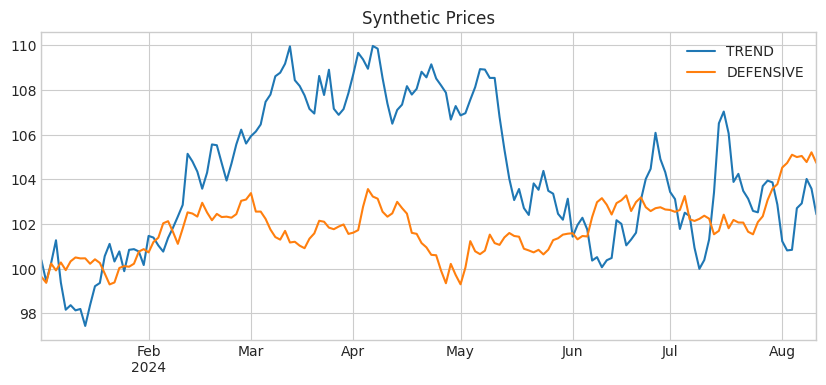

In [19]:
price_df.plot(figsize=(10, 4), title="Synthetic Prices")
plt.show()

## 2. 定义一个事件驱动策略

这个策略每隔 `rebalance_every` 个交易日检查一次过去 `lookback` 日收益：

- 如果 `TREND` 的过去收益更强，则持有 `TREND=100%`
- 否则持有 `DEFENSIVE=100%`
- 非调仓日不发订单，持仓随价格自然漂移

这正是事件驱动回测和每日矩阵回测的一个重要区别：策略只在事件发生时交易。

In [20]:
strategy = SimpleRelativeMomentumEventStrategy(lookback=20, rebalance_every=20)
strategy

## 3. 运行事件驱动回测

当前事件引擎采用研究型简化执行口径：订单按当前 snapshot 价格立即成交，佣金按成交 notional 乘以 `commission_rate` 计算。

In [21]:
result = strategy.run_event_backtest(
    price_df=price_df,
    initial_cash=1.0,
    commission_rate=0.0005,
)
result.nav.tail()

2024-08-06    0.957986
2024-08-07    0.960002
2024-08-08    0.970215
2024-08-09    0.966143
2024-08-12    0.955457
Name: nav, dtype: float64

## 4. 查看结果

`EventRecorder` 会输出标准 `BacktestResult`：`nav`、`returns`、`positions_df`、`turnover_series`、`fee_log` 等字段。

In [22]:
summary = pd.Series(
    {
        "start": result.nav.index.min(),
        "end": result.nav.index.max(),
        "final_nav": result.nav.iloc[-1],
        "total_return": result.nav.iloc[-1] - 1.0,
        "num_rebalance_days": int((result.turnover_series > 0).sum()),
        "total_commission": float(result.fee_log["commission"].sum()),
    }
)
summary

start                 2024-01-02 00:00:00
end                   2024-08-12 00:00:00
final_nav                        0.955457
total_return                    -0.044543
num_rebalance_days                      7
total_commission                 0.003501
dtype: object

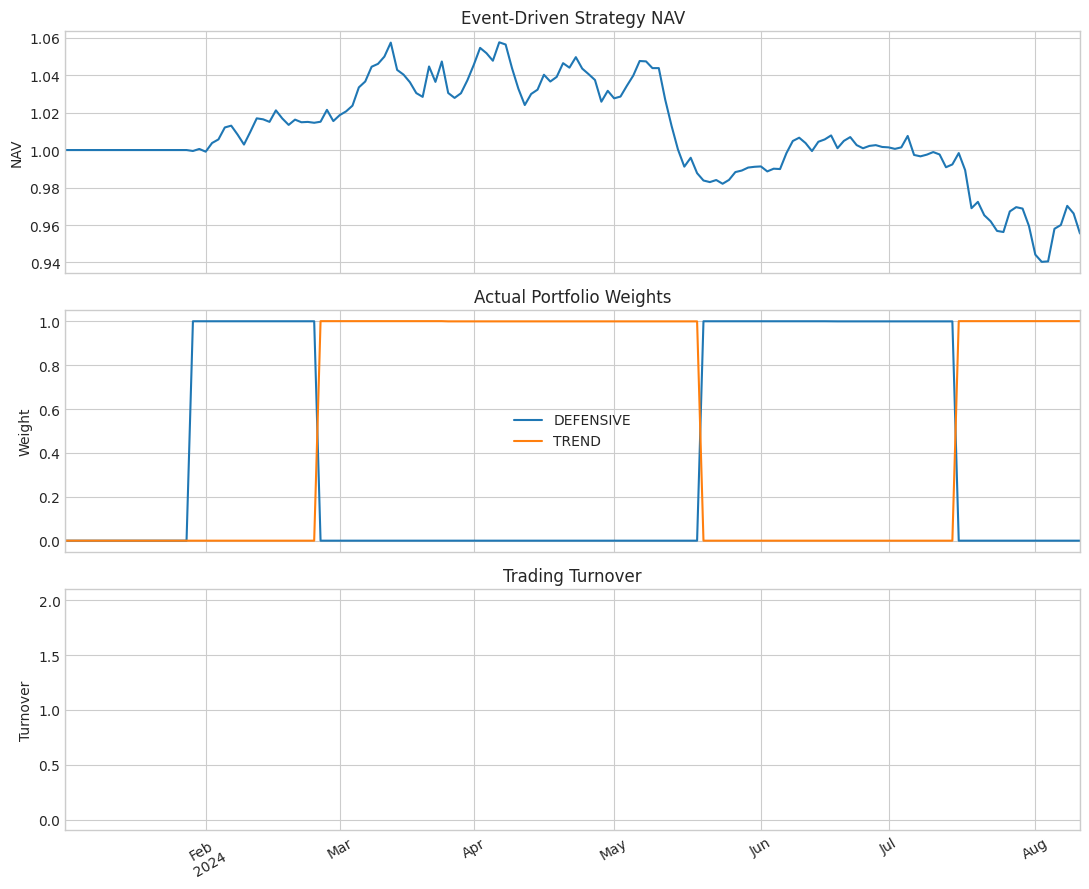

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

result.nav.plot(ax=axes[0], title="Event-Driven Strategy NAV")
axes[0].set_ylabel("NAV")

result.positions_df.plot(ax=axes[1], title="Actual Portfolio Weights")
axes[1].set_ylabel("Weight")

turnover_to_plot = result.turnover_series[result.turnover_series > 0]
axes[2].vlines(turnover_to_plot.index, 0.0, turnover_to_plot.values)
axes[2].scatter(turnover_to_plot.index, turnover_to_plot.values, s=24)
axes[2].set_title("Trading Turnover")
axes[2].set_ylabel("Turnover")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [26]:
result.positions_df.tail()

,DEFENSIVE,TREND
2024-08-06,0.0,1.001043
2024-08-07,0.0,1.001041
2024-08-08,0.0,1.001030
2024-08-09,0.0,1.001034
2024-08-12,0.0,1.001046


In [27]:
result.fee_log[result.fee_log["commission"] > 0].head()

,commission
date,
2024-01-30,5.000000e-04
2024-02-27,1.016376e-03
2024-03-26,5.081878e-07
2024-04-23,2.540939e-10
2024-05-21,9.844855e-04


## 当前边界

这个示例使用的是轻量研究型事件驱动回测：

- 支持 market snapshot 推进、策略 callback、订单、持仓状态、费用和 `BacktestResult`
- 支持非调仓日持仓漂移和真实交易换手记录
- 尚未建模滑点、拒单、部分成交、多撮合时点或生产交易 gateway

因此它适合用来研究“状态/事件/稀疏交易”类策略的回测逻辑，而不是替代生产交易系统。